- Yol haritamız şu şekilde olacak
    - Kütüphanelerin import edilmesi
    - Veri setinin yüklenmesi ve metin verilerinin alınması
    - Metin temizleme
    - Tokenizasyon
    - Word2Vec modelinin tanımlanması
    - Clustering (kümeleme)
    - PCA
    - Görselleştirme

In [1]:
# Kütüphanelerimizi import edelim

import pandas as pd
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import re

In [9]:
# Veri setini yükleyelim

df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# Metin verilerimizi alalım

documents = df["review"][:10000] # veri seti 50k çok büyük olduğu için 10000 ile sınırlıyorum
documents[:5]

0    One of the other reviewers has mentioned that ...
1    A wonderful little production. <br /><br />The...
2    I thought this was a wonderful way to spend ti...
3    Basically there's a family where a little boy ...
4    Petter Mattei's "Love in the Time of Money" is...
Name: review, dtype: object

In [18]:
# Metin temizleme işlemi için fonksiyon tanımlayalım

def clean_text(text):
    # küçük harfe çevirme
    text = text.lower()

    # rakamları silelim
    text = re.sub(r"\d+", "", text)

    # özel karakterleri silelim
    text = re.sub(r"[^\w\s]", "", text)

    # "a", "I" gibi tek karakterleri silelim
    text = " ".join([word for word in text.split() if len(word) > 2])

    # stop words'leri silelim
    import nltk
    from nltk.corpus import stopwords
    nltk.download("stopwords")
    stop_words = set(stopwords.words("english"))
    text = " ".join([word for word in text.split() if word not in stop_words])
    
    return text

In [19]:
# Fonksiyonumuzu kullanarak metinleri temizleyelim

cleaned_documents = [clean_text(doc) for doc in documents]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\BedirhanOrseloglu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\BedirhanOrseloglu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\BedirhanOrseloglu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\BedirhanOrseloglu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\BedirhanOrseloglu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\BedirhanOrseloglu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\

In [ ]:
# Temizlediğimiz cümleleri token'lara (kelimelere) bölelim

tokenized_document = [simple_preprocess(doc) for doc in cleaned_documents]
tokenized_document[0] # ilk cümlenin token'larını örnek olarak inceleyelim

# ilk satırımız şuydu: 
# "One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
 

['one',
 'reviewers',
 'mentioned',
 'watching',
 'episode',
 'youll',
 'hooked',
 'right',
 'exactly',
 'happened',
 'mebr',
 'first',
 'thing',
 'struck',
 'brutality',
 'unflinching',
 'scenes',
 'violence',
 'set',
 'right',
 'word',
 'trust',
 'show',
 'faint',
 'hearted',
 'timid',
 'show',
 'pulls',
 'punches',
 'regards',
 'drugs',
 'sex',
 'violence',
 'hardcore',
 'classic',
 'use',
 'wordbr',
 'called',
 'nickname',
 'given',
 'oswald',
 'maximum',
 'security',
 'state',
 'penitentary',
 'focuses',
 'mainly',
 'emerald',
 'city',
 'experimental',
 'section',
 'prison',
 'cells',
 'glass',
 'fronts',
 'face',
 'inwards',
 'privacy',
 'high',
 'agenda',
 'city',
 'home',
 'manyaryans',
 'muslims',
 'gangstas',
 'latinos',
 'christians',
 'italians',
 'irish',
 'moreso',
 'scuffles',
 'death',
 'stares',
 'dodgy',
 'dealings',
 'shady',
 'agreements',
 'never',
 'far',
 'awaybr',
 'would',
 'say',
 'main',
 'appeal',
 'show',
 'due',
 'fact',
 'goes',
 'shows',
 'wouldnt',
 'da

In [24]:
# Word2Vec modelini tanımlayalım

word2vec_model = Word2Vec(sentences=tokenized_document, vector_size=50, window=5, min_count=1, sg=0) # sg=0 ise BoW


In [ ]:
# Modelimiz içerisindeki kelime vektörlerine erişelim

# Aslında bir önceki derste yazdığımız "plot_word_embeddings" fonksiyonunun aynısını parça parça yazacağız. 
    # Orda birden fazla modelde aynı işlemleri yapacağımız için fonksiyon haline getirmiştik.

word_vectors = word2vec_model.wv
words = list(word_vectors.index_to_key)[:500] # ilk 500 kelimeyi alalım çok uzun sürmesin diye
vectors = [word_vectors[word] for word in words]

In [27]:
# Kümeleme (clustering) işlemi için KMeans algoritmasını kullanalım

kmeans = KMeans(n_clusters=5)
kmeans.fit(vectors) # vektörlerimizi kümeleyelim
clusters = kmeans.labels_ # her kelimenin hangi kümeye ait olduğunu alalım

In [30]:
# PCA ile boyut indirgeme yapalım (50 boyuttan 2 boyuta. Görselleştirme yapabilmek için)

pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)

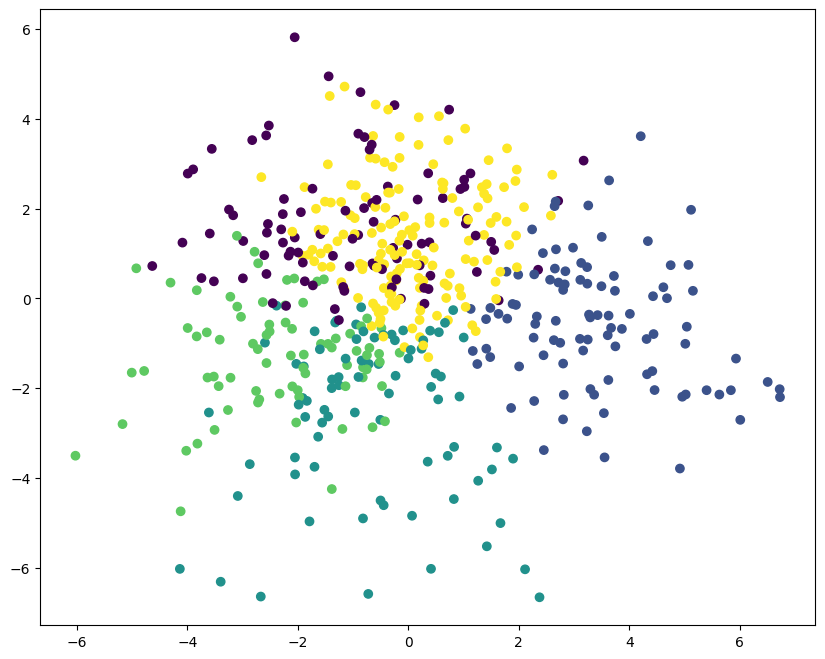

In [32]:
# Görselleştirelim

plt.figure(figsize=(10, 8))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], cmap="viridis" , c=clusters) # tüm satırların x ve y'sini aldım  # renkleri kümelere göre ayarladım


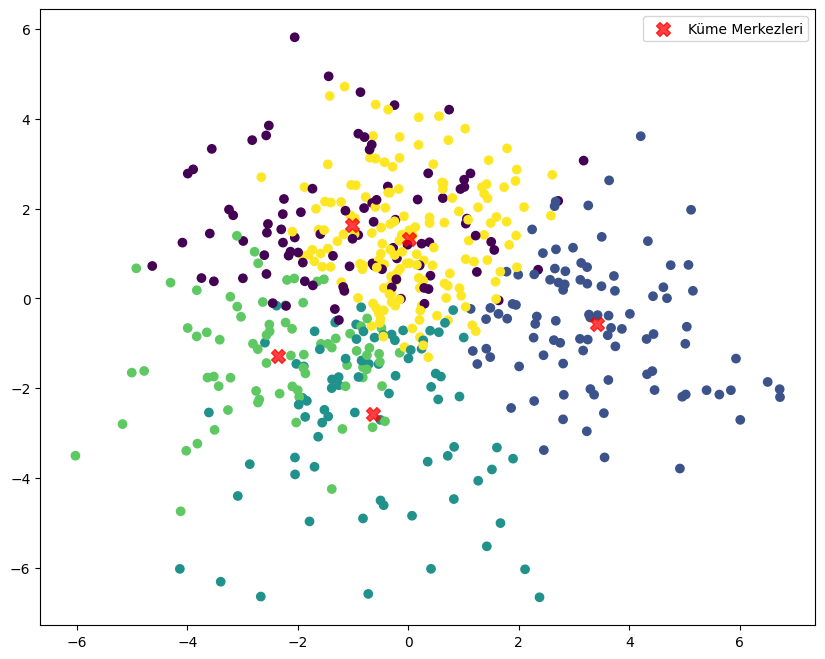

In [39]:
 # Küme merkezlerini işaretleyelim

plt.figure(figsize=(10, 8))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], cmap="viridis" , c=clusters) # tüm satırların x ve y'sini aldım  # renkleri kümelere göre ayarladım

centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.75, marker='X', label="Küme Merkezleri")  # küme merkezlerini işaretleyelim
plt.legend()

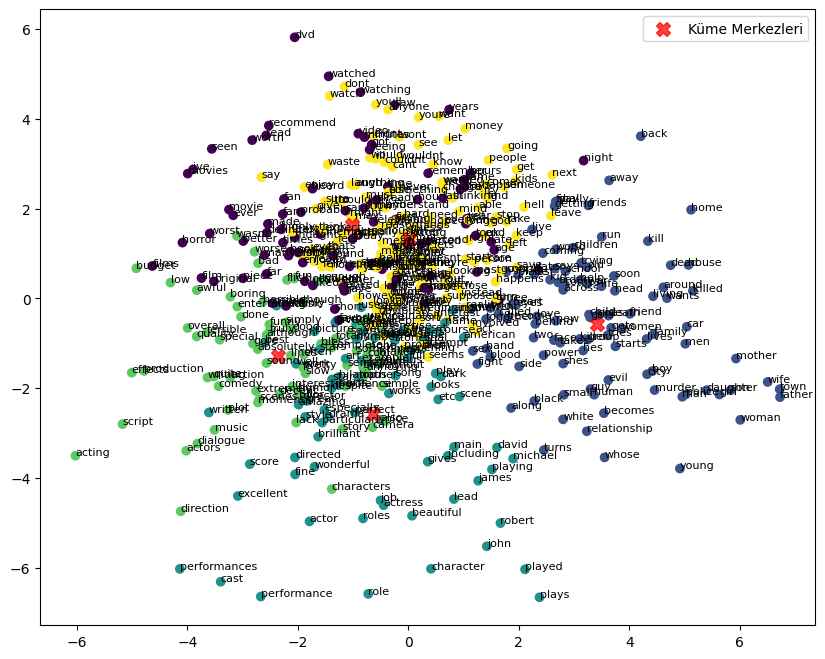

In [ ]:
# Figure üzerine kelimeleri de yazalım 

plt.figure(figsize=(10, 8))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], cmap="viridis" , c=clusters) # tüm satırların x ve y'sini aldım  # renkleri kümelere göre ayarladım

centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.75, marker='X', label="Küme Merkezleri")  # küme merkezlerini işaretleyelim
plt.legend()

for i, word in enumerate(words):
    plt.text(reduced_vectors[i,0], reduced_vectors[i,1], word, fontsize=8)  # her kelimenin x ve y'sine text olarak kelimeyi yazalım


# Geçen derste kendimiz gözle bakarak hangi kelime birbiri ile ilişkili diye düşünmüştük.
# Şimdi ise KMeans algoritması ile kelimeleri kümelere ayırdık. Bu sayede benzer anlamlı kelimeler aynı kümede yer alıyor.


Örneğin incelediğimizde mother, wife, father, women kelimelerinin aynı kümede ve birbirine yakın olduğunu görüyoruz

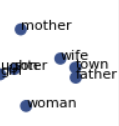